# PSAR Backtest & Analysis

This notebook recomputes indicators/trades (if needed) and adds 15 analysis charts/tables requested by the user. Run cells in order.

In [ ]:
# Install ta library if not already installed
!pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=d73d31533aeebcceb5944fbe09b308b33d5a23e7d29091462acaed64ef9aa174
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [ ]:
# Imports and plotting settings
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datetime import datetime
plt.style.use('dark_background')
sns.set_palette('tab10')

# USD formatting helper for chart axes
import matplotlib.ticker as mtick

def fmt_usd(ax):
    """Format y-axis tick labels as USD with commas"""
    ax.yaxis.set_major_formatter(
        mtick.FuncFormatter(lambda x, _: f'${x:,.0f}')
    )


In [ ]:
# Utility: drawdown series function
def compute_drawdown(equity_series):
    running_max = equity_series.cummax()
    drawdown = equity_series / running_max - 1
    return drawdown, running_max


In [ ]:
# Parameters - adjust if needed
USE_CSV = False
CSV_PATH = 'sp500_daily.csv'
TICKER = '^GSPC'
START = '2000-01-01'
END = '2025-12-31'

# PSAR Parameters (Default values from J. Welles Wilder Jr.)
PSAR_INITIAL_ACCELERATION = 0.02
PSAR_ACCELERATION_INCREMENT = 0.02
PSAR_MAX_ACCELERATION = 0.2

MC_SIMULATIONS = 10000
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
INITIAL_CAPITAL = 100_000  # USD - starting capital for dollar-value equity displays

In [ ]:
# Data loading (WILL ALWAYS RECOMPUTE DF for robust processing)
# The 'if 'df' not in globals():' check is temporarily removed to ensure a fresh start.
print(f'Downloading {TICKER} from Yahoo Finance: {START} to {END} ...')
data = yf.download(TICKER, start=START, end=END, progress=False)

# Reset index to make 'Date' a column. This might result in a column named 'Date', 'level_0', 'index', or an unnamed one.
df = data.reset_index()

# Robust column name standardization
standard_names = {
    'date': 'Date', 'open': 'Open', 'high': 'High', 'low': 'Low',
    'close': 'Close', 'adj close': 'Adj Close', 'volume': 'Volume'
}

processed_columns = []
for col in df.columns:
    if isinstance(col, tuple):
        # Handle MultiIndex columns, which can be ('Attribute', 'Ticker') or ('Date', '')
        if col[0].lower() == 'date':
            processed_columns.append('Date')
        elif len(col) > 1 and col[1] == TICKER: # E.g., ('Close', '^GSPC')
            processed_columns.append(standard_names.get(col[0].lower(), col[0]))
        elif len(col) > 1 and col[1] == '': # E.g., ('Date', '')
            processed_columns.append(standard_names.get(col[0].lower(), col[0]))
        else: # Fallback for unexpected tuples
            processed_columns.append('_'.join(map(str, col)).strip())
    else:
        # Handle single-level string columns
        processed_columns.append(standard_names.get(str(col).lower(), col))
df.columns = processed_columns

# Ensure 'Date' column is present after initial processing
if 'Date' not in df.columns:
    # If 'Date' not found, try renaming the first column if it's a common date-like name
    possible_date_cols = [col for col in df.columns if str(col).lower() in ['level_0', 'index', 'ticker']]
    if possible_date_cols:
        df = df.rename(columns={possible_date_cols[0]: 'Date'})
    else:
        # If 'Date' is still missing, this is a critical failure.
        raise KeyError("Could not identify a 'Date' column after all renaming attempts.")

df['Date'] = pd.to_datetime(df['Date']) # Convert to datetime immediately

# Handle 'Adj Close': if 'Close' exists, drop 'Adj Close', else rename 'Adj Close' to 'Close'
if 'Adj Close' in df.columns:
    if 'Close' in df.columns:
        df = df.drop(columns=['Adj Close'], axis=1)
    else:
        df = df.rename(columns={'Adj Close': 'Close'})

# Final selection of required columns
required_cols = ['Date','Open','High','Low','Close','Volume']
# Filter df to only include columns that are in required_cols and actually exist
df = df[[col for col in required_cols if col in df.columns]]

missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise KeyError(f"Missing required columns after data loading: {missing_cols}. Available columns: {df.columns.tolist()}")

print('Download complete. Rows:', len(df))

# Ensure sorted (always after data loading, even if df exists)
df = df.sort_values('Date').reset_index(drop=True)
df['Date'] = pd.to_datetime(df['Date']) # Redundant but harmless, ensures type.
df.head()

/tmp/ipykernel_9474/1292103018.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(TICKER, start=START, end=END, progress=False)


Download complete. Rows: 6538


,Date,Open,High,Low,Close,Volume
0,2000-01-03,1469.250000,1478.000000,1438.359985,1455.219971,931800000
1,2000-01-04,1455.219971,1455.219971,1397.430054,1399.420044,1009000000
2,2000-01-05,1399.420044,1413.270020,1377.680054,1402.109985,1085500000
3,2000-01-06,1402.109985,1411.900024,1392.099976,1403.449951,1092300000
4,2000-01-07,1403.449951,1441.469971,1400.729980,1441.469971,1225200000


In [ ]:
"""
# Uncomment this cell if you wish to get the daily data in csv
from google.colab import files

# Save the DataFrame to a CSV file
output_filename = 'GSPC_20000101_20251231_dataframe_export.csv'
df.to_csv(output_filename, index=False)

# Provide a download link for the user
files.download(output_filename)
print(f'Your DataFrame has been exported to {output_filename} and is ready for download.')
"""

"\n# Uncomment this cell if you wish to get the daily data in csv\nfrom google.colab import files\n\n# Save the DataFrame to a CSV file\noutput_filename = 'GSPC_20000101_20251231_dataframe_export.csv'\ndf.to_csv(output_filename, index=False)\n\n# Provide a download link for the user\nfiles.download(output_filename)\nprint(f'Your DataFrame has been exported to {output_filename} and is ready for download.')\n"

In [ ]:
import ta.trend # Import for PSAR calculation

# Recompute SMA, position, returns, equity
# Fix: Flatten MultiIndex columns if present
# The column flattening logic has been moved to the data loading cell (h4P0DDtZJQxL) for correct execution order.
# if isinstance(df.columns, pd.MultiIndex):
#     # Assuming the relevant column names are in the second level of the MultiIndex
#     df.columns = df.columns.get_level_values(1)

# Calculate PSAR
df['PSAR'] = ta.trend.PSARIndicator(df['High'], df['Low'], df['Close'],
                           step=PSAR_INITIAL_ACCELERATION, # Renamed from initial_acceleration
                           max_step=PSAR_MAX_ACCELERATION).psar() # Renamed from max_acceleration; acceleration_increment is not a direct parameter

# --- Parabolic SAR Strategy Logic (Standard Long-Only Trend Following) ---
# Note: The user's literal interpretation "Go long when PSAR crosses above close" and "Exit when close crosses above PSAR"
# is counter-intuitive for a long strategy. This implementation uses the standard PSAR trend-following logic for long positions.
# Entry (Go Long): PSAR flips from being ABOVE price to BELOW price.
# Exit (Close Long): PSAR flips from being BELOW price to ABOVE price.

# Initialize 'Position' to 0 (cash)
df['Position'] = 0

current_position = 0 # 0 for cash, 1 for long

for i in range(1, len(df)): # Start from 1 to access i-1
    # Entry Condition (Go Long):
    # PSAR was above or equal to Close, and now PSAR is below Close (bullish flip)
    if (df['PSAR'].iloc[i-1] >= df['Close'].iloc[i-1]) and \
       (df['PSAR'].iloc[i] < df['Close'].iloc[i]):
        current_position = 1

    # Exit Condition (Close Long Position):
    # PSAR was below Close, and now PSAR is above or equal to Close (bearish flip)
    elif (df['PSAR'].iloc[i-1] < df['Close'].iloc[i-1]) and \
         (df['PSAR'].iloc[i] >= df['Close'].iloc[i]):
        current_position = 0

    df.loc[df.index[i], 'Position'] = current_position


df['Market_Return'] = df['Close'].pct_change().fillna(0)
df['Strategy_Return'] = df['Market_Return'] * df['Position'].shift(1).fillna(0)
df['Equity'] = (1 + df['Strategy_Return']).cumprod()
# Buy & Hold equity for comparison (mark-to-market)
df['B&H_Return'] = df['Market_Return']
df['B&H_Equity'] = (1 + df['B&H_Return']).cumprod()
df.tail()

# --- SMA200 + Cash (interest-bearing when out of market) ---
# Download historical 3-month T-Bill rate (^IRX = annualised %)
print('Downloading T-Bill rate (^IRX)...')
tbill_raw = yf.download('^IRX', start=START, end=END, progress=False)
tbill_raw = tbill_raw.reset_index()

# Flatten MultiIndex columns if present (same pattern as main data load)
tbill_raw.columns = [col[0] if isinstance(col, tuple) else col for col in tbill_raw.columns]
tbill_raw['Date'] = pd.to_datetime(tbill_raw['Date'])

# Convert annualised % to daily rate, then align to df['Date']
tbill_daily = (1 + tbill_raw.set_index('Date')['Close'] / 100) ** (1 / 252) - 1
tbill_daily = tbill_daily.reindex(df['Date']).ffill().bfill().fillna(0.0)
tbill_daily = tbill_daily.values  # numpy array aligned to df

# When Position==1: earn market return. When Position==0: earn daily T-Bill rate.
position_prev = df['Position'].shift(1).fillna(0)
df['Cash_Return'] = df['Market_Return'] * position_prev + tbill_daily * (1 - position_prev)
df['Cash_Equity'] = (1 + df['Cash_Return']).cumprod()
print('Cash equity computed.')

# Dollar-value equity columns
df['Equity_$']      = df['Equity']      * INITIAL_CAPITAL
df['B&H_Equity_$']  = df['B&H_Equity']  * INITIAL_CAPITAL
df['Cash_Equity_$'] = df['Cash_Equity'] * INITIAL_CAPITAL

/tmp/ipykernel_9474/3997478844.py:53: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tbill_raw = yf.download('^IRX', start=START, end=END, progress=False)


Cash equity computed.


In [ ]:
# Trade extraction (entry when prev pos==0 and pos==1; exit when prev pos==1 and pos==0)
trades = []
in_trade = False
entry_idx = None
for i in range(1, len(df)):
    prev_pos = df.at[i-1, 'Position']
    pos = df.at[i, 'Position']
    if (not in_trade) and (prev_pos == 0) and (pos == 1):
        in_trade = True
        entry_idx = i
    if in_trade and (prev_pos == 1) and (pos == 0):
        exit_idx = i
        entry_price = df.at[entry_idx, 'Close']
        exit_price = df.at[exit_idx, 'Close']
        pnl = exit_price / entry_price - 1
        highs = df.loc[entry_idx:exit_idx, 'High']
        lows = df.loc[entry_idx:exit_idx, 'Low']
        mfe = (highs.max() / entry_price) - 1
        mae = (lows.min() / entry_price) - 1
        trades.append({'entry_idx': entry_idx, 'exit_idx': exit_idx, 'entry_date': df.at[entry_idx,'Date'], 'exit_date': df.at[exit_idx,'Date'], 'entry_price': entry_price, 'exit_price': exit_price, 'pnl': pnl, 'mfe': mfe, 'mae': mae})
        in_trade = False
        entry_idx = None
# close if still in trade
if in_trade and entry_idx is not None:
    exit_idx = len(df)-1
    entry_price = df.at[entry_idx, 'Close']
    exit_price = df.at[exit_idx, 'Close']
    pnl = exit_price / entry_price - 1
    highs = df.loc[entry_idx:exit_idx, 'High']
    lows = df.loc[entry_idx:exit_idx, 'Low']
    mfe = (highs.max() / entry_price) - 1
    mae = (lows.min() / entry_price) - 1
    trades.append({'entry_idx': entry_idx, 'exit_idx': exit_idx, 'entry_date': df.at[entry_idx,'Date'], 'exit_date': df.at[exit_idx,'Date'], 'entry_price': entry_price, 'exit_price': exit_price, 'pnl': pnl, 'mfe': mfe, 'mae': mae})
trades_df = pd.DataFrame(trades)
print('Number of trades:', len(trades_df))
trades_df.head()

Number of trades: 337


,entry_idx,exit_idx,entry_date,exit_date,entry_price,exit_price,pnl,mfe,mae
0,9,15,2000-01-14,2000-01-25,1465.150024,1410.030029,-0.037621,0.005358,-0.052322
1,23,32,2000-02-04,2000-02-17,1424.369995,1388.260010,-0.025352,0.014168,-0.033783
2,41,61,2000-03-02,2000-03-30,1381.760010,1487.920044,0.076830,0.123835,-0.025431
3,78,89,2000-04-25,2000-05-10,1477.439941,1383.050049,-0.063887,0.003723,-0.069241
4,104,124,2000-06-01,2000-06-29,1448.810059,1442.390015,-0.004431,0.027692,-0.019471


In [ ]:
# Export trades to CSV
if not trades_df.empty:
    # Add a dollar PnL column for convenience
    export_df = trades_df.copy()
    export_df['pnl_pct']     = (export_df['pnl'] * 100).round(4)
    export_df['mfe_pct']     = (export_df['mfe'] * 100).round(4)
    export_df['mae_pct']     = (export_df['mae'] * 100).round(4)
    export_df['pnl_usd']     = (export_df['pnl'] * INITIAL_CAPITAL).round(2)

    # Clean up columns for export (drop raw index cols, keep meaningful ones)
    export_cols = [
        'entry_date', 'exit_date',
        'entry_price', 'exit_price',
        'pnl', 'pnl_pct', 'pnl_usd',
        'mfe', 'mfe_pct',
        'mae', 'mae_pct'
    ]
    export_df = export_df[export_cols]

    # Build a filename with the ticker and date range
    csv_filename = f"trades_{TICKER.replace('^','')}_{START}_{END}.csv"
    export_df.to_csv(csv_filename, index=False)
    print(f"Trades exported to: {csv_filename}")
    print(f"Total trades: {len(export_df)}")
    display(export_df.head())
else:
    print("No trades to export.")

Trades exported to: trades_GSPC_2000-01-01_2025-12-31.csv
Total trades: 337


,entry_date,exit_date,entry_price,exit_price,pnl,pnl_pct,pnl_usd,mfe,mfe_pct,mae,mae_pct
0,2000-01-14,2000-01-25,1465.150024,1410.030029,-0.037621,-3.7621,-3762.07,0.005358,0.5358,-0.052322,-5.2322
1,2000-02-04,2000-02-17,1424.369995,1388.260010,-0.025352,-2.5352,-2535.15,0.014168,1.4168,-0.033783,-3.3783
2,2000-03-02,2000-03-30,1381.760010,1487.920044,0.076830,7.6830,7682.96,0.123835,12.3835,-0.025431,-2.5431
3,2000-04-25,2000-05-10,1477.439941,1383.050049,-0.063887,-6.3887,-6388.75,0.003723,0.3723,-0.069241,-6.9241
4,2000-06-01,2000-06-29,1448.810059,1442.390015,-0.004431,-0.4431,-443.13,0.027692,2.7692,-0.019471,-1.9471


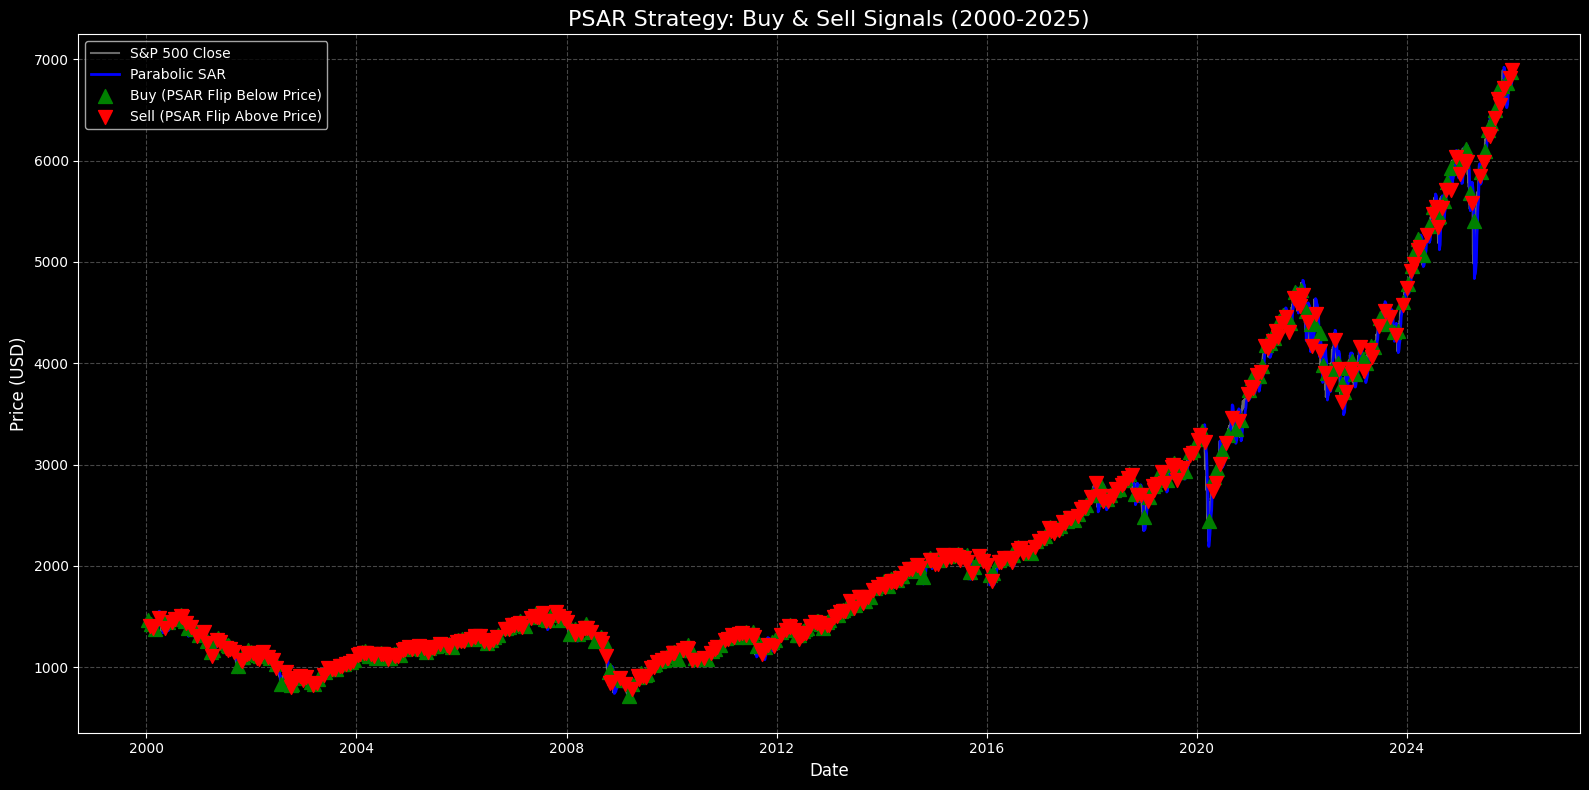

In [ ]:
def plot_strategy_signals_fixed(df, trades_df):
    """
    Plots the Price, PSAR, and Buy/Sell signals.
    """
    plt.figure(figsize=(16, 8))

    # Ensure we are working with datetime objects for comparison
    df_plot = df.copy()
    df_plot['Date'] = pd.to_datetime(df_plot['Date'])
    trades_plot = trades_df.copy()
    trades_plot['entry_date'] = pd.to_datetime(trades_plot['entry_date'])
    trades_plot['exit_date'] = pd.to_datetime(trades_plot['exit_date'])

    # 1. Plot the S&P 500 Close Price and the PSAR
    plt.plot(df_plot['Date'], df_plot['Close'], label='S&P 500 Close', color='lightgray', alpha=0.5)
    plt.plot(df_plot['Date'], df_plot['PSAR'], label='Parabolic SAR', color='blue', linewidth=2)

    # 2. Extract Entry and Exit points by matching the Date column
    entries = df_plot[df_plot['Date'].isin(trades_plot['entry_date'])]
    exits = df_plot[df_plot['Date'].isin(trades_plot['exit_date'])]

    # 3. Plot Buy/Sell Markers using the Date as the x-coordinate
    plt.scatter(entries['Date'], entries['Close'],
                label='Buy (PSAR Flip Below Price)', marker='^', color='green', s=100, zorder=5)
    plt.scatter(exits['Date'], exits['Close'],
                label='Sell (PSAR Flip Above Price)', marker='v', color='red', s=100, zorder=5)

    # Formatting
    plt.title('PSAR Strategy: Buy & Sell Signals (2000-2025)', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Price (USD)', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.7, color='#666666')

    plt.tight_layout()
    plt.show()

# Run the fixed function
plot_strategy_signals_fixed(df, trades_df)


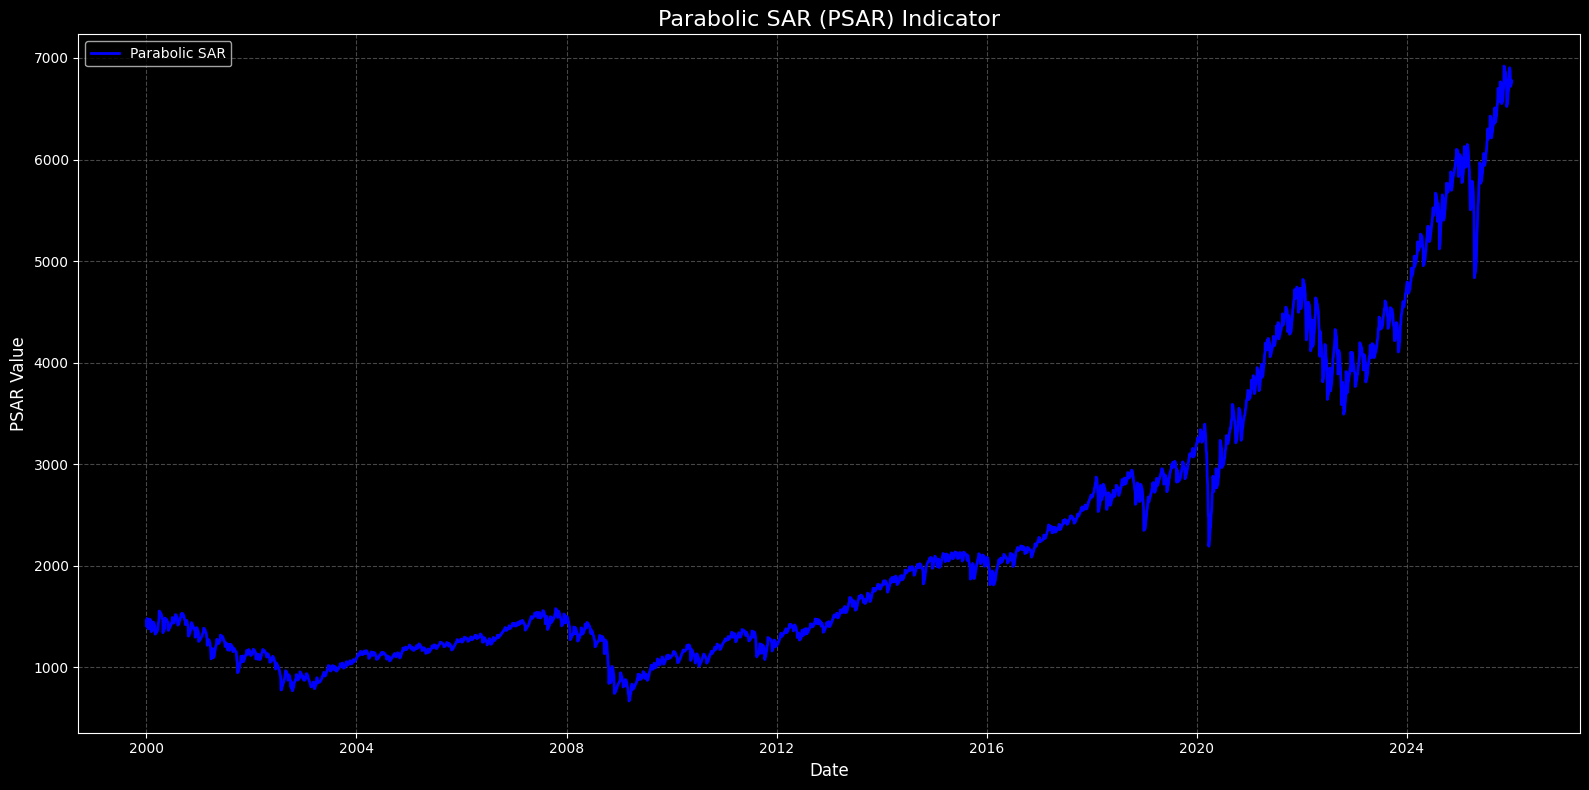

In [ ]:
plt.figure(figsize=(16, 8))
plt.plot(df['Date'], df['PSAR'], label='Parabolic SAR', color='blue', linewidth=2)
plt.title('Parabolic SAR (PSAR) Indicator', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('PSAR Value', fontsize=12)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.7, color='#666666')
plt.tight_layout()
plt.show()


In [ ]:
# Performance summary table (Page 1)
total_days = (df['Date'].iloc[-1] - df['Date'].iloc[0]).days / 365.25
cagr = df['Equity'].iloc[-1] ** (1/total_days) - 1
drawdown, _ = compute_drawdown(df['Equity'])
max_dd = drawdown.min()
ann_ret = df['Strategy_Return'].mean() * 252
ann_vol = df['Strategy_Return'].std() * np.sqrt(252)
sharpe = ann_ret / ann_vol if ann_vol!=0 else np.nan
# trade stats
if not trades_df.empty:
    wins = trades_df[trades_df['pnl']>0]
    losses = trades_df[trades_df['pnl']<=0]
    profit_factor = wins['pnl'].sum() / (-losses['pnl'].sum()) if losses['pnl'].sum()!=0 else np.nan
    win_rate = len(wins)/len(trades_df)
    avg_trade = trades_df['pnl'].mean()
else:
    profit_factor = np.nan
    win_rate = np.nan
    avg_trade = np.nan
summary = pd.DataFrame([{
    'CAGR': cagr, 'Max_Drawdown': max_dd, 'Annualized_Return': ann_ret, 'Annualized_Vol': ann_vol, 'Sharpe': sharpe, 'Num_Trades': len(trades_df), 'Win_Rate': win_rate, 'Profit_Factor': profit_factor, 'Avg_Trade_PnL': avg_trade
}])
print('Performance summary (Page 1):')
display(summary.T.rename(columns={0:'Value'}))


Performance summary (Page 1):


,Value
CAGR,0.002033
Max_Drawdown,-0.513537
Annualized_Return,0.009573
Annualized_Vol,0.122612
Sharpe,0.078072
Num_Trades,337.000000
Win_Rate,0.445104
Profit_Factor,1.058695
Avg_Trade_PnL,0.000670


### Comprehensive Performance Metrics

In [ ]:
# Comprehensive Performance Metrics
from datetime import timedelta

def compute_sortino_ratio(returns, risk_free_rate=0):
    downside_returns = returns[returns < risk_free_rate]
    if len(downside_returns) == 0: return np.nan
    downside_deviation = downside_returns.std() * np.sqrt(252) # Annualized
    if downside_deviation == 0: return np.nan
    return (returns.mean() * 252 - risk_free_rate) / downside_deviation

def compute_ulcer_index(equity_series):
    if equity_series.empty: return np.nan
    peak = equity_series.cummax()
    drawdown = ((peak - equity_series) / peak) ** 2
    return np.sqrt(drawdown.mean())

def compute_max_consecutive_wins_losses(pnl_series):
    if pnl_series.empty: return 0, 0
    consecutive_wins = 0
    max_consecutive_wins = 0
    consecutive_losses = 0
    max_consecutive_losses = 0

    for pnl in pnl_series:
        if pnl > 0:
            consecutive_wins += 1
            consecutive_losses = 0
        elif pnl < 0:
            consecutive_losses += 1
            consecutive_wins = 0
        else:
            consecutive_wins = 0
            consecutive_losses = 0
        max_consecutive_wins = max(max_consecutive_wins, consecutive_wins)
        max_consecutive_losses = max(max_consecutive_losses, consecutive_losses)
    return max_consecutive_wins, max_consecutive_losses

def compute_longest_flat_period(equity_series, dates):
    if equity_series.empty: return timedelta(0)
    peak_dates = dates[equity_series.diff().fillna(0) > 0]
    if peak_dates.empty: return timedelta(0) # No peaks, no flat periods

    max_flat_duration = timedelta(0)
    last_peak_date = dates.iloc[0]

    for i in range(1, len(dates)):
        current_date = dates.iloc[i]
        current_equity = equity_series.iloc[i]

        # If new peak or higher than last peak
        if current_equity >= equity_series[dates == last_peak_date].iloc[0]:
            # Calculate duration of the flat period just ended
            flat_duration = current_date - last_peak_date
            max_flat_duration = max(max_flat_duration, flat_duration)
            last_peak_date = current_date

    return max_flat_duration

def compute_max_time_to_recover(equity_series, dates):
    if equity_series.empty: return timedelta(0)
    max_recovery_time = timedelta(0)
    peak_date = dates.iloc[0]
    max_peak_equity = equity_series.iloc[0]
    recovery_start_date = None

    for i in range(1, len(dates)):
        current_date = dates.iloc[i]
        current_equity = equity_series.iloc[i]

        if current_equity > max_peak_equity:
            max_peak_equity = current_equity
            peak_date = current_date
            recovery_start_date = None # Reset recovery period
        elif current_equity < max_peak_equity and recovery_start_date is None:
            # Entering a drawdown, start tracking potential recovery time
            recovery_start_date = current_date

        if recovery_start_date is not None and current_equity >= max_peak_equity:
            # Recovered to previous peak
            recovery_time = current_date - recovery_start_date
            max_recovery_time = max(max_recovery_time, recovery_time)
            recovery_start_date = None # Reset for next drawdown

    # Handle case where still in drawdown at end of series
    if recovery_start_date is not None:
        # Consider the time from the start of the last drawdown to the end of the series
        max_recovery_time = max(max_recovery_time, dates.iloc[-1] - recovery_start_date)

    return max_recovery_time


if not trades_df.empty:
    wins = trades_df[trades_df['pnl'] > 0]
    losses = trades_df[trades_df['pnl'] <= 0]

    # Basic Profit/Loss
    total_net_profit_val = df['Equity'].iloc[-1] - 1
    gross_profit_val = wins['pnl'].sum()
    gross_loss_val = losses['pnl'].sum()

    # Profitability
    profit_factor_val = gross_profit_val / abs(gross_loss_val) if gross_loss_val != 0 else np.nan
    total_trades_val = len(trades_df)
    winning_trades_val = len(wins)
    losing_trades_val = len(losses)
    even_trades_val = total_trades_val - winning_trades_val - losing_trades_val
    percent_profitable_val = (winning_trades_val / total_trades_val) * 100 if total_trades_val > 0 else np.nan
    win_rate_val = winning_trades_val / total_trades_val if total_trades_val > 0 else np.nan # Added for Kelly

    # Averages
    avg_trade_pnl_val = trades_df['pnl'].mean()
    avg_winning_trade_val = wins['pnl'].mean() if winning_trades_val > 0 else np.nan
    avg_losing_trade_val = losses['pnl'].mean() if losing_trades_val > 0 else np.nan
    ratio_avg_win_avg_loss_val = abs(avg_winning_trade_val / avg_losing_trade_val) if (avg_winning_trade_val is not np.nan and avg_losing_trade_val is not np.nan and avg_losing_trade_val != 0) else np.nan

    # Consecutive Wins/Losses
    max_consec_winners_val, max_consec_losses_val = compute_max_consecutive_wins_losses(trades_df['pnl'])

    # Largest Trades
    largest_winning_trade_val = wins['pnl'].max() if winning_trades_val > 0 else np.nan
    largest_losing_trade_val = losses['pnl'].min() if losing_trades_val > 0 else np.nan

    # Time-based Metrics
    total_days_in_backtest_val = (df['Date'].iloc[-1] - df['Date'].iloc[0]).days
    avg_trades_per_day_val = total_trades_val / total_days_in_backtest_val if total_days_in_backtest_val > 0 else np.nan

    # Calculate trade durations and average time in market
    trade_durations_val = (trades_df['exit_date'] - trades_df['entry_date']).dt.days
    avg_time_in_market_days_val = trade_durations_val.mean() if not trade_durations_val.empty else np.nan
    # Convert timedelta to fraction of a day
    if avg_time_in_market_days_val is not np.nan:
        avg_time_in_market_val = f'{avg_time_in_market_days_val:.2f} days' # Display as days for clarity, no longer a timedelta string
    else:
        avg_time_in_market_val = 'N/A'

    # Profit per month
    total_months_val = total_days_in_backtest_val / 30.4375
    profit_per_month_val = total_net_profit_val / total_months_val if total_months_val > 0 else np.nan

    # Drawdown related
    max_dd_equity_pct_val, _ = compute_drawdown(df['Equity'])
    max_drawdown_percent_val = max_dd_equity_pct_val.min()

    max_time_to_recover_val = compute_max_time_to_recover(df['Equity'], df['Date'])
    longest_flat_period_val = compute_longest_flat_period(df['Equity'], df['Date'])

    # Risk-adjusted Returns
    cagr_val = df['Equity'].iloc[-1] ** (1/total_days_in_backtest_val * 365.25) - 1 if total_days_in_backtest_val > 0 else np.nan
    ann_vol_val = df['Strategy_Return'].std() * np.sqrt(252) if not df['Strategy_Return'].empty else np.nan
    sharpe_ratio_val = cagr_val / ann_vol_val if ann_vol_val != 0 else np.nan

    sortino_ratio_val = compute_sortino_ratio(df['Strategy_Return'])
    ulcer_index_val = compute_ulcer_index(df['Equity'])

    # Kelly Criterion Calculation
    if win_rate_val is not np.nan and ratio_avg_win_avg_loss_val is not np.nan and ratio_avg_win_avg_loss_val > 0:
        kelly_criterion_val = win_rate_val - (1 - win_rate_val) / ratio_avg_win_avg_loss_val
    else:
        kelly_criterion_val = np.nan

    # Excursion Metrics
    avg_mae_val = trades_df['mae'].mean() if not trades_df['mae'].empty else np.nan
    avg_mfe_val = trades_df['mfe'].mean() if not trades_df['mfe'].empty else np.nan

    # End Trade Drawdown (ETD) - distance from trade high to trade close
    # Calculate ETD for each trade: (high_in_trade - exit_price) / high_in_trade
    etd_list_val = []
    for _, trade in trades_df.iterrows():
        entry_idx = trade['entry_idx']
        exit_idx = trade['exit_idx']
        highs = df.loc[entry_idx:exit_idx, 'High']
        if not highs.empty:
            max_high_in_trade = highs.max()
            exit_price = trade['exit_price']
            if max_high_in_trade > exit_price: # Only consider drawdown if high was above exit
                etd_list_val.append((max_high_in_trade - exit_price) / max_high_in_trade)
            else:
                etd_list_val.append(0) # No drawdown from peak if exit was the peak or higher
        else:
            etd_list_val.append(np.nan)
    avg_etd_val = np.mean(etd_list_val) if etd_list_val else np.nan

    # Dictionary to hold both formatted and USD values
    metrics_data = {
        'Total Net Profit': {'Value': f'{total_net_profit_val:.2%}', 'Value (USD)': f'${total_net_profit_val * INITIAL_CAPITAL:,.2f}'},
        'Gross Profit': {'Value': f'{gross_profit_val:.2%}', 'Value (USD)': f'${gross_profit_val * INITIAL_CAPITAL:,.2f}'},
        'Gross Loss': {'Value': f'{gross_loss_val:.2%}', 'Value (USD)': f'${gross_loss_val * INITIAL_CAPITAL:,.2f}'},
        'Profit Factor': {'Value': f'{profit_factor_val:.2f}' if profit_factor_val is not np.nan else 'N/A', 'Value (USD)': 'N/A'},
        'Max. Drawdown (Equity)': {'Value': f'{max_drawdown_percent_val:.2%}', 'Value (USD)': 'N/A'},
        'Sharpe Ratio': {'Value': f'{sharpe_ratio_val:.2f}' if sharpe_ratio_val is not np.nan else 'N/A', 'Value (USD)': 'N/A'},
        'Sortino Ratio': {'Value': f'{sortino_ratio_val:.2f}' if sortino_ratio_val is not np.nan else 'N/A', 'Value (USD)': 'N/A'},
        'Ulcer Index': {'Value': f'{ulcer_index_val:.4f}' if ulcer_index_val is not np.nan else 'N/A', 'Value (USD)': 'N/A'},
        'Kelly Criterion': {'Value': f'{kelly_criterion_val:.2%}' if kelly_criterion_val is not np.nan else 'N/A', 'Value (USD)': 'N/A'},
        'Total # of Trades': {'Value': total_trades_val, 'Value (USD)': 'N/A'},
        'Percent Profitable': {'Value': f'{percent_profitable_val:.2f}%' if percent_profitable_val is not np.nan else 'N/A', 'Value (USD)': 'N/A'},
        '# of Winning Trades': {'Value': winning_trades_val, 'Value (USD)': 'N/A'},
        '# of Losing Trades': {'Value': losing_trades_val, 'Value (USD)': 'N/A'},
        '# of Even Trades': {'Value': even_trades_val, 'Value (USD)': 'N/A'},
        'Avg. Trade PnL': {'Value': f'{avg_trade_pnl_val:.2%}', 'Value (USD)': f'${avg_trade_pnl_val * INITIAL_CAPITAL:,.2f}'},
        'Avg. Winning Trade PnL': {'Value': f'{avg_winning_trade_val:.2%}' if avg_winning_trade_val is not np.nan else 'N/A', 'Value (USD)': f'${avg_winning_trade_val * INITIAL_CAPITAL:,.2f}' if avg_winning_trade_val is not np.nan else 'N/A'},
        'Avg. Losing Trade PnL': {'Value': f'{avg_losing_trade_val:.2%}' if avg_losing_trade_val is not np.nan else 'N/A', 'Value (USD)': f'${avg_losing_trade_val * INITIAL_CAPITAL:,.2f}' if avg_losing_trade_val is not np.nan else 'N/A'},
        'Ratio Avg. Win/Avg. Loss': {'Value': f'{ratio_avg_win_avg_loss_val:.2f}' if ratio_avg_win_avg_loss_val is not np.nan else 'N/A', 'Value (USD)': 'N/A'},
        'Max. Consec. Winners': {'Value': max_consec_winners_val, 'Value (USD)': 'N/A'},
        'Max. Consec. Losers': {'Value': max_consec_losses_val, 'Value (USD)': 'N/A'},
        'Largest Winning Trade PnL': {'Value': f'{largest_winning_trade_val:.2%}' if largest_winning_trade_val is not np.nan else 'N/A', 'Value (USD)': f'${largest_winning_trade_val * INITIAL_CAPITAL:,.2f}' if largest_winning_trade_val is not np.nan else 'N/A'},
        'Largest Losing Trade PnL': {'Value': f'{largest_losing_trade_val:.2%}' if largest_losing_trade_val is not np.nan else 'N/A', 'Value (USD)': f'${largest_losing_trade_val * INITIAL_CAPITAL:,.2f}' if largest_losing_trade_val is not np.nan else 'N/A'},
        'Avg. # of Trades per Day': {'Value': f'{avg_trades_per_day_val:.2f}' if avg_trades_per_day_val is not np.nan else 'N/A', 'Value (USD)': 'N/A'},
        'Avg. Time in Market': {'Value': avg_time_in_market_val, 'Value (USD)': 'N/A'},
        'Profit per Month': {'Value': f'{profit_per_month_val:.2%}' if profit_per_month_val is not np.nan else 'N/A', 'Value (USD)': f'${profit_per_month_val * INITIAL_CAPITAL:,.2f}' if profit_per_month_val is not np.nan else 'N/A'},
        'Max. Time to Recover': {'Value': f'{max_time_to_recover_val.total_seconds() / (24 * 3600):.2f} days' if isinstance(max_time_to_recover_val, timedelta) else str(max_time_to_recover_val), 'Value (USD)': 'N/A'},
        'Longest Flat Period': {'Value': f'{longest_flat_period_val.total_seconds() / (24 * 3600):.2f} days' if isinstance(longest_flat_period_val, timedelta) else str(longest_flat_period_val), 'Value (USD)': 'N/A'},
        'Avg. MAE': {'Value': f'{avg_mae_val:.2%}' if avg_mae_val is not np.nan else 'N/A', 'Value (USD)': 'N/A'},
        'Avg. MFE': {'Value': f'{avg_mfe_val:.2%}' if avg_mfe_val is not np.nan else 'N/A', 'Value (USD)': 'N/A'},
        'Avg. ETD': {'Value': f'{avg_etd_val:.2%}' if avg_etd_val is not np.nan else 'N/A', 'Value (USD)': 'N/A'}
    }

    metrics_df = pd.DataFrame.from_dict(metrics_data, orient='index')
    print("Comprehensive Performance Metrics:")
    display(metrics_df)
else:
    print("No trades available to compute comprehensive performance metrics.")

Comprehensive Performance Metrics:


,Value,Value (USD)
Total Net Profit,5.42%,"$5,418.98"
Gross Profit,407.27%,"$407,268.25"
Gross Loss,-384.69%,"$-384,689.02"
Profit Factor,1.06,N/A
Max. Drawdown (Equity),-51.35%,N/A
Sharpe Ratio,0.02,N/A
Sortino Ratio,0.08,N/A
Ulcer Index,0.3018,N/A
Kelly Criterion,2.47%,N/A
Total # of Trades,337,N/A


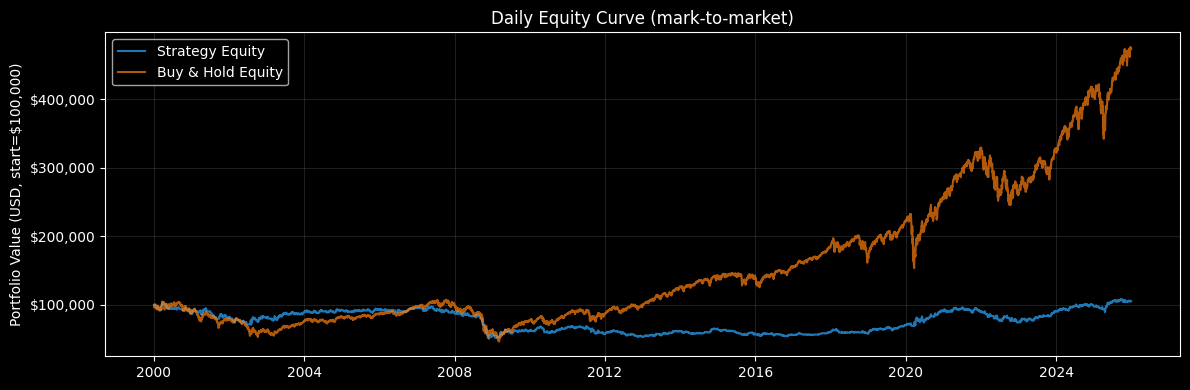

In [ ]:
# Page 2: Daily equity curve (mark-to-market)
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(df['Date'], df['Equity_$'], label='Strategy Equity')
ax.plot(df['Date'], df['B&H_Equity_$'], label='Buy & Hold Equity', alpha=0.7)
ax.set_title('Daily Equity Curve (mark-to-market)')
ax.set_ylabel(f'Portfolio Value (USD, start=${INITIAL_CAPITAL:,})')
fmt_usd(ax)
ax.legend()
ax.grid(True, alpha=0.3, color='#666666')
plt.tight_layout(); plt.show()


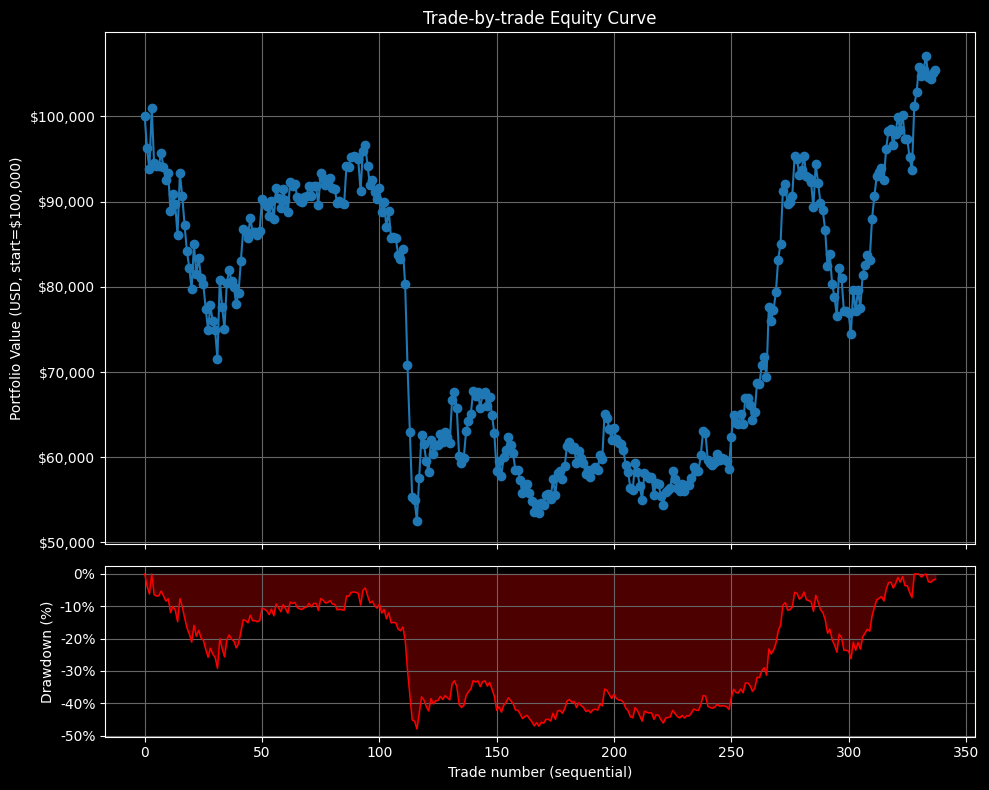

In [ ]:
# Page 3: Trade-by-trade equity curve (with Drawdown)
# Build a capital path that applies each trade sequentially
if not trades_df.empty:
    trade_caps = [INITIAL_CAPITAL]
    cap = INITIAL_CAPITAL
    for r in trades_df['pnl'].values:
        cap = cap * (1 + r)
        trade_caps.append(cap)
    trade_caps = np.array(trade_caps)

    # --- ADDED: Drawdown Calculation ---
    trade_caps_series = pd.Series(trade_caps)
    drawdowns = (trade_caps_series / trade_caps_series.cummax()) - 1
    # ------------------------------------

    # Create two subplots: top for Equity, bottom for Drawdown
    fig, (ax, ax_dd) = plt.subplots(2, 1, figsize=(10, 8), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})

    # Top Plot (Your Original Plotting Logic)
    ax.plot(range(len(trade_caps)), trade_caps, marker='o')
    ax.set_ylabel(f'Portfolio Value (USD, start=${INITIAL_CAPITAL:,})')
    ax.set_title('Trade-by-trade Equity Curve')
    fmt_usd(ax)
    ax.grid(True, color='#666666')

    # Bottom Plot (The New Drawdown Plot)
    ax_dd.fill_between(range(len(drawdowns)), drawdowns, 0, color='red', alpha=0.3)
    ax_dd.plot(range(len(drawdowns)), drawdowns, color='red', linewidth=1)
    ax_dd.set_ylabel('Drawdown (%)')
    ax_dd.set_xlabel('Trade number (sequential)')
    ax_dd.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax_dd.grid(True, color='#666666')

    plt.tight_layout()
    plt.show()
else:
    print('No trades to plot trade-by-trade equity')


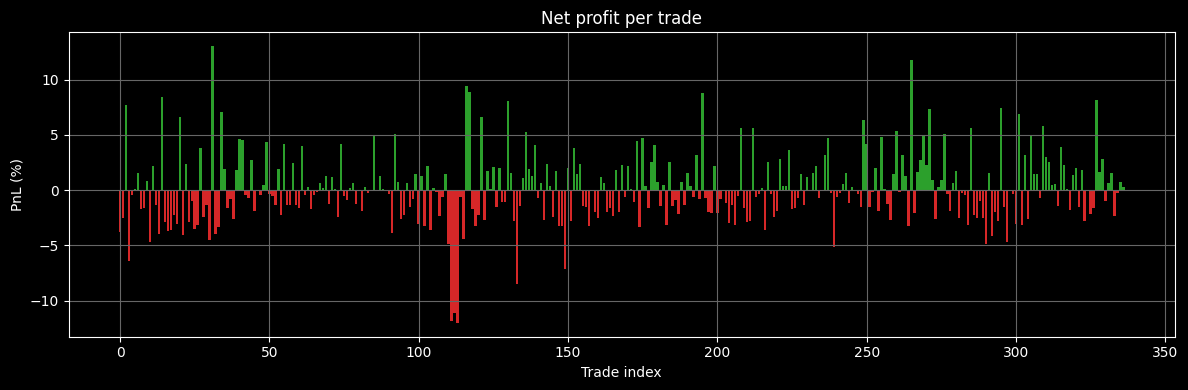

In [ ]:
# Page 4: Net profit per trade (bar chart)
if not trades_df.empty:
    fig, ax = plt.subplots(figsize=(12,4))
    ax.bar(range(len(trades_df)), trades_df['pnl'] * 100, color=np.where(trades_df['pnl']>0, 'tab:green', 'tab:red'))
    ax.set_xlabel('Trade index')
    ax.set_ylabel('PnL (%)')
    ax.set_title('Net profit per trade')
    plt.grid(True, color='#666666')
    plt.tight_layout(); plt.show()
else:
    print('No trades to plot')


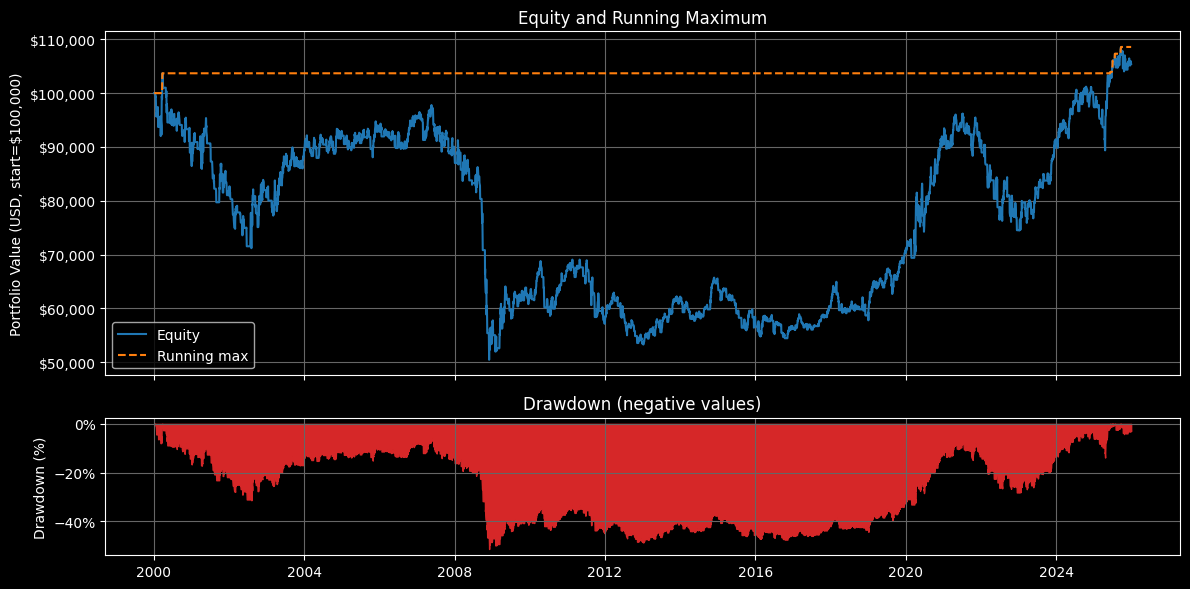

In [ ]:
# Page 5: Cumulative maximum drawdown (plot running max and drawdown)
dd, running_max = compute_drawdown(df['Equity_$'])
fig, ax = plt.subplots(2,1, figsize=(12,6), sharex=True, gridspec_kw={'height_ratios':[1,0.4]})
ax[0].plot(df['Date'], df['Equity_$'], label='Equity')
ax[0].plot(df['Date'], running_max, label='Running max', linestyle='--')
ax[0].legend(); ax[0].set_title('Equity and Running Maximum')
ax[0].set_ylabel(f'Portfolio Value (USD, start=${INITIAL_CAPITAL:,})')
fmt_usd(ax[0])
ax[0].grid(True, color='#666666')
ax[1].fill_between(df['Date'], dd, 0, color='tab:red')
ax[1].set_ylabel('Drawdown (%)')
ax[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax[1].set_title('Drawdown (negative values)')
ax[1].grid(True, color='#666666')
plt.tight_layout(); plt.show()


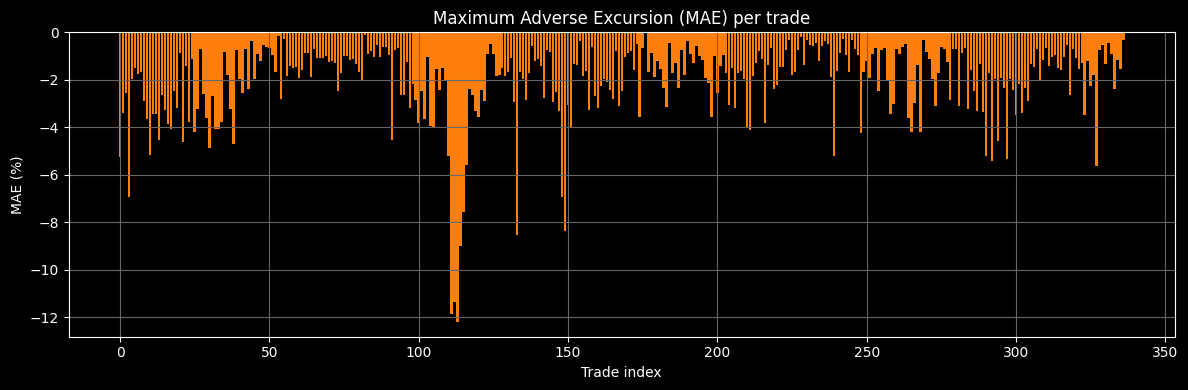

In [ ]:
# Page 6: MAE bar chart (per trade)
if not trades_df.empty:
    fig, ax = plt.subplots(figsize=(12,4))
    ax.bar(range(len(trades_df)), trades_df['mae'] * 100, color='tab:orange')
    ax.set_xlabel('Trade index')
    ax.set_ylabel('MAE (%)')
    ax.set_title('Maximum Adverse Excursion (MAE) per trade')
    plt.grid(True, color='#666666')
    plt.tight_layout(); plt.show()
else:
    print('No trades to plot MAE')


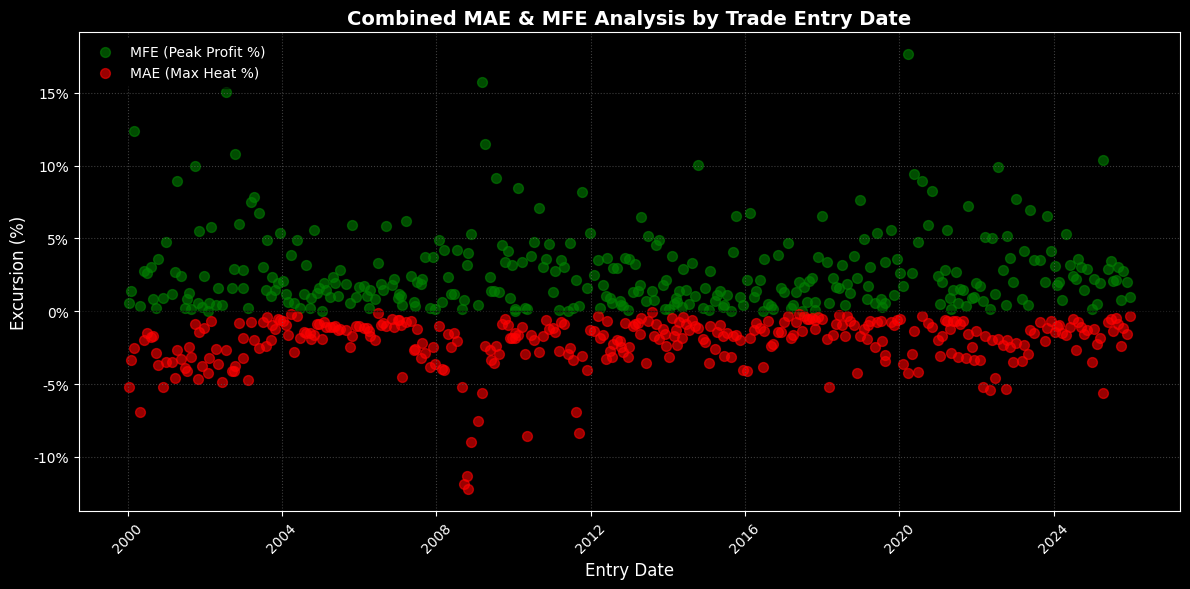

In [ ]:
# Page 7: Combined MAE & MFE Scatter Chart by Entry Date
if not trades_df.empty:
    # Ensure entry_date is treated as a date for the x-axis
    trades_df['entry_date'] = pd.to_datetime(trades_df['entry_date'])

    # Calculate percentage columns for plotting if not already present
    trades_df['pnl_pct'] = (trades_df['pnl'] * 100).round(4)
    trades_df['mfe_pct'] = (trades_df['mfe'] * 100).round(4)
    trades_df['mae_pct'] = (trades_df['mae'] * 100).round(4)

    fig, ax = plt.subplots(figsize=(12, 6))

    # 1. Plot MFE (Maximum Favorable Excursion) in Green
    # Using your original logic of multiplying by 100 if the column is a fraction
    # Or using mfe_pct if available in your DataFrame
    ax.scatter(trades_df['entry_date'], trades_df['mfe_pct'],
               c='green', alpha=0.6, s=50, label='MFE (Peak Profit %)')

    # 2. Plot MAE (Maximum Adverse Excursion) in Red
    ax.scatter(trades_df['entry_date'], trades_df['mae_pct'],
               c='red', alpha=0.6, s=50, label='MAE (Max Heat %)')

    # 3. Reference and Formatting
    ax.axhline(0, color='black', linewidth=1, alpha=0.5)
    ax.set_xlabel('Entry Date', fontsize=12)
    ax.set_ylabel('Excursion (%)', fontsize=12)
    ax.set_title('Combined MAE & MFE Analysis by Trade Entry Date', fontsize=14, fontweight='bold')

    # Format Y-axis as percentage
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

    # 4. Legend with Box at Top Left
    # loc='upper left' moves it, frameon=True adds the box, edgecolor adds the border
    ax.legend(loc='upper left', frameon=True, edgecolor='black', fancybox=False, shadow=True)

    plt.xticks(rotation=45)
    ax.grid(True, linestyle=':', alpha=0.6, color='#666666')
    plt.tight_layout()
    plt.show()
else:
    print('No trades to plot excursion scatter')


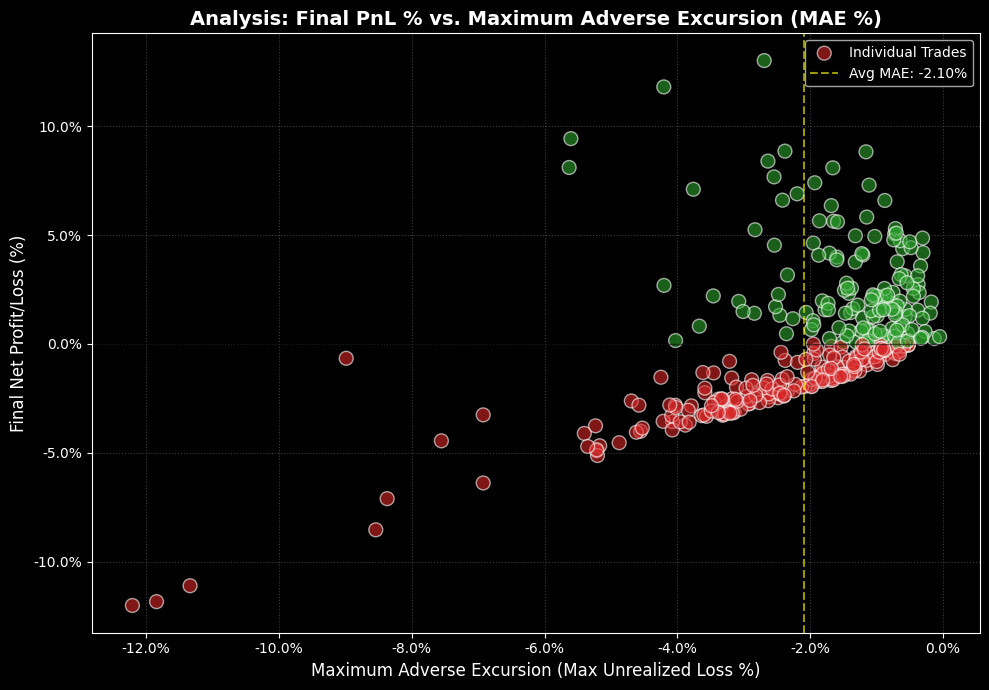

In [ ]:
# Page 8: MAE Analysis (PnL % vs. Maximum Adverse Excursion)
if not trades_df.empty:
    fig, ax = plt.subplots(figsize=(10, 7))

    # 2. Define colors based on trade outcome (Green for Profit, Red for Loss)
    colors = ['#2ca02c' if x > 0 else '#d62728' for x in trades_df['pnl_pct']]

    # 3. Create the scatter plot
    # Note: MAE is typically negative, so it will appear on the left side of the Y-axis
    ax.scatter(trades_df['mae_pct'], trades_df['pnl_pct'],
               c=colors, alpha=0.6, edgecolors='white', s=100, label='Individual Trades')

    # 4. Add reference lines
    ax.axhline(0, color='black', linewidth=1, alpha=0.5) # Zero PnL line

    # Add a vertical line for Average MAE to show the typical "risk" taken
    avg_mae = trades_df['mae_pct'].mean()
    ax.axvline(avg_mae, color='yellow', linestyle='--', alpha=0.6,
               label=f'Avg MAE: {avg_mae:.2f}%')

    # 5. Formatting and Labels
    ax.set_title('Analysis: Final PnL % vs. Maximum Adverse Excursion (MAE %)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Maximum Adverse Excursion (Max Unrealized Loss %)', fontsize=12)
    ax.set_ylabel('Final Net Profit/Loss (%)', fontsize=12)

    # Format axes as percentages
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))

    ax.grid(True, linestyle=':', alpha=0.6, color='#666666')
    ax.legend()

    plt.tight_layout()
    plt.show()
else:
    print("No trade data available to plot.")


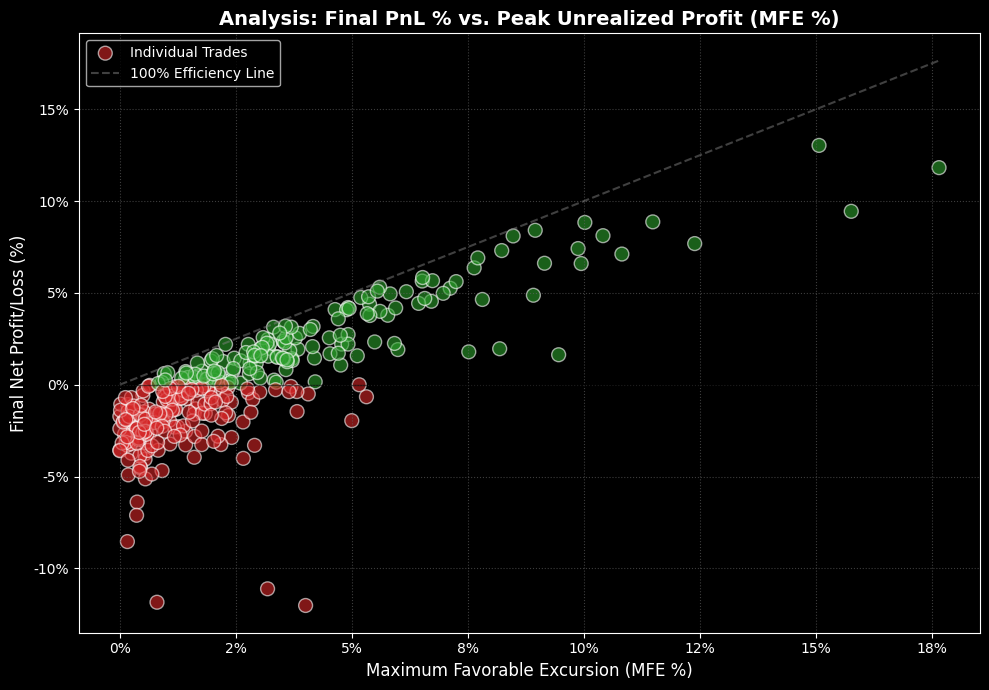

In [ ]:
# Page 9: MFE Analysis (PnL % vs. Maximum Favorable Excursion)
if not trades_df.empty:
    # Ensure percentage columns are available for plotting
    trades_df['pnl_pct'] = (trades_df['pnl'] * 100).round(4)
    trades_df['mfe_pct'] = (trades_df['mfe'] * 100).round(4)
    trades_df['mae_pct'] = (trades_df['mae'] * 100).round(4)

    fig, ax = plt.subplots(figsize=(10, 7))

    # 2. Define colors based on trade outcome
    colors = ['#2ca02c' if x > 0 else '#d62728' for x in trades_df['pnl_pct']]

    # 3. Create the scatter plot
    ax.scatter(trades_df['mfe_pct'], trades_df['pnl_pct'],
               c=colors, alpha=0.6, edgecolors='white', s=100, label='Individual Trades')

    # 4. Add the 100% Efficiency Line (PnL = MFE)
    # This represents exiting at the exact peak of the trade
    max_val = max(trades_df['mfe_pct'].max(), trades_df['pnl_pct'].max())
    ax.plot([0, max_val], [0, max_val], color='gray', linestyle='--', alpha=0.5, label='100% Efficiency Line')

    # 5. Formatting and Labels
    ax.set_title('Analysis: Final PnL % vs. Peak Unrealized Profit (MFE %)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Maximum Favorable Excursion (MFE %)', fontsize=12)
    ax.set_ylabel('Final Net Profit/Loss (%)', fontsize=12)

    # Add horizontal line at zero
    ax.axhline(0, color='black', linewidth=1, alpha=0.5)

    # Format axes as percentages
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

    ax.grid(True, linestyle=':', alpha=0.6, color='#666666')
    ax.legend()

    plt.tight_layout()
    plt.show()
else:
    print("No trade data available to plot.")


### Interest from Idle Cash

Meb Faber, co-founder and CIO of Cambria Investment Management, explicitly built this concept of putting idle cash into interest bearing instruments into his landmark 2006 white paper "A Quantitative Approach to Tactical Asset Allocation" (QTAA), published on SSRN. In that paper, when his market-timing model moved to cash (i.e. price below the 10-month SMA), the portfolio was explicitly parked in T-bills, earning the collateral yield. He describes the total return as consisting of the "collateral yield (cash sitting in T-bills), trend following, and rebalancing." He even published a follow-up post specifically exploring alternative cash strategies when out of the market.

Citation: Faber, M. T. (2007). A Quantitative Approach to Tactical Asset Allocation. The Journal of Wealth Management, Spring 2007. Available at SSRN: https://ssrn.com/abstract=962461


Gary Antonacci, author of Dual Momentum Investing (2014), independently formalised the same idea. In his Dual Momentum strategy, when the absolute momentum rule signals "out of equities," the capital rotates into T-bills or aggregate bonds rather than sitting idle.

Citation: Antonacci, G. (2014). Dual Momentum Investing: An Innovative Strategy for Higher Returns with Lower Risk. McGraw-Hill Education.

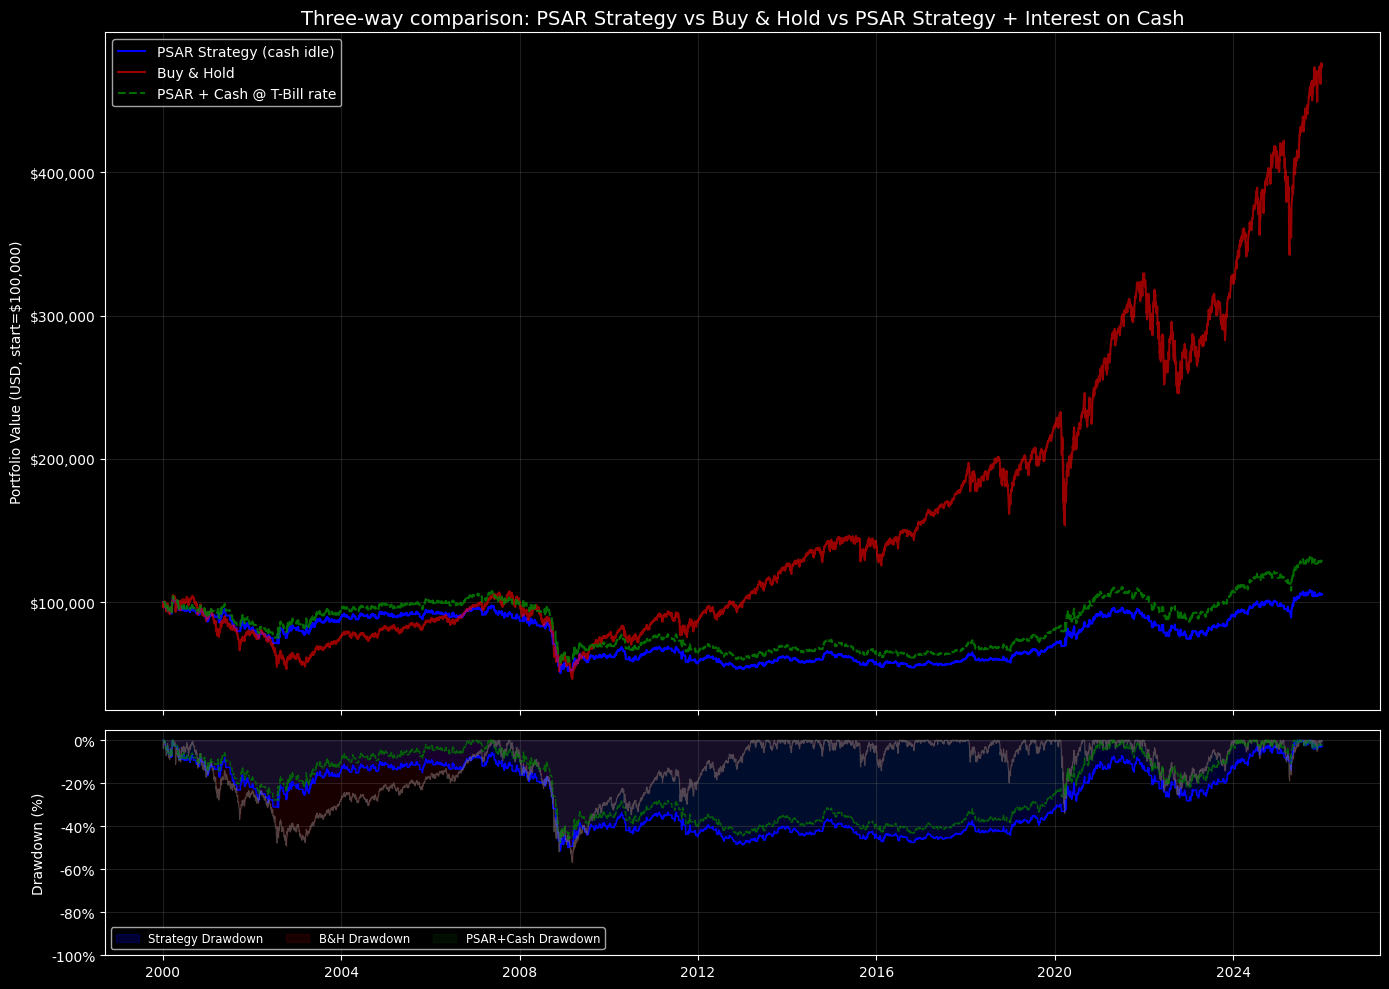

In [ ]:
# Page 10: Three-way comparison vs Buy & Hold (Equity curves & Drawdown)

# 1. Calculate Drawdowns for each of the 3 strategies
df['Drawdown_Strategy'] = (df['Equity_$'] / df['Equity_$'].cummax()) - 1
df['Drawdown_B&H'] = (df['B&H_Equity_$'] / df['B&H_Equity_$'].cummax()) - 1
df['Drawdown_Cash_Strategy'] = (df['Cash_Equity_$'] / df['Cash_Equity_$'].cummax()) - 1

# 2. Set up a figure with two subplots (sharing the X-axis for dates)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})

# --- TOP SUBPLOT: Equity Curves ---
ax1.plot(df['Date'], df['Equity_$'],      label='PSAR Strategy (cash idle)', color='blue')
ax1.plot(df['Date'], df['B&H_Equity_$'],  label='Buy & Hold', color='red', alpha=0.6)
ax1.plot(df['Date'], df['Cash_Equity_$'], label='PSAR + Cash @ T-Bill rate', color='green', alpha=0.85, linestyle='--')

ax1.set_title('Three-way comparison: PSAR Strategy vs Buy & Hold vs PSAR Strategy + Interest on Cash', fontsize=14)
ax1.set_ylabel(f'Portfolio Value (USD, start=${INITIAL_CAPITAL:,})')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3, color='#666666')
if 'fmt_usd' in globals(): fmt_usd(ax1) # Applying the formatting function from your notebook

# --- BOTTOM SUBPLOT: Drawdown Curves ---
ax2.fill_between(df['Date'], df['Drawdown_Strategy'], 0, color='blue', alpha=0.2, label='Strategy Drawdown')
ax2.plot(df['Date'], df['Drawdown_Strategy'], color='blue', linewidth=1)

ax2.fill_between(df['Date'], df['Drawdown_B&H'], 0, color='red', alpha=0.1, label='B&H Drawdown')
ax2.plot(df['Date'], df['Drawdown_B&H'], color='gray', linewidth=0.8, alpha=0.5)

ax2.fill_between(df['Date'], df['Drawdown_Cash_Strategy'], 0, color='green', alpha=0.1, label='PSAR+Cash Drawdown')
ax2.plot(df['Date'], df['Drawdown_Cash_Strategy'], color='green', linewidth=1, linestyle='--', alpha=0.7)

ax2.set_ylabel('Drawdown (%)')
ax2.set_ylim(-1.0, 0.05) # Focus on 0 to -100%
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax2.legend(loc='lower left', fontsize='small', ncol=3)
ax2.grid(True, alpha=0.3, color='#666666')

plt.tight_layout()
plt.show()


In [ ]:
# Page 11: Monte Carlo summary table (bootstrap trades)
def monte_carlo_from_trades(trade_pnls, n_sim=1000):
    if len(trade_pnls)==0:
        return np.array([])
    results = np.empty(n_sim)
    m = len(trade_pnls)
    for i in range(n_sim):
        sample = np.random.choice(trade_pnls, size=m, replace=True)
        capital = 1.0
        for r in sample:
            capital *= (1 + r)
        results[i] = capital
    return results
if not trades_df.empty:
    mc_results = monte_carlo_from_trades(trades_df['pnl'].values, n_sim=MC_SIMULATIONS)
    if mc_results.size>0:
        pctiles = np.percentile(mc_results, [5,25,50,75,95])
        mc_summary = pd.DataFrame({
            'Percentile': [5, 25, 50, 75, 95],
            'Final_Capital (x)': pctiles,
            'Final_Capital (USD)': pctiles * INITIAL_CAPITAL
        })
        mc_summary['Final_Capital (USD)'] = mc_summary['Final_Capital (USD)'].apply(
            lambda x: f'${x:,.0f}'
        )
        print('Monte Carlo summary (Page 11):')
        display(mc_summary)
    else:
        print('MC returned no results')
else:
    print('Not enough trades for Monte Carlo bootstrap')

Monte Carlo summary (Page 11):


,Percentile,Final_Capital (x),Final_Capital (USD)
0,5,0.410581,"$41,058"
1,25,0.720410,"$72,041"
2,50,1.062425,"$106,242"
3,75,1.573559,"$157,356"
4,95,2.760675,"$276,068"


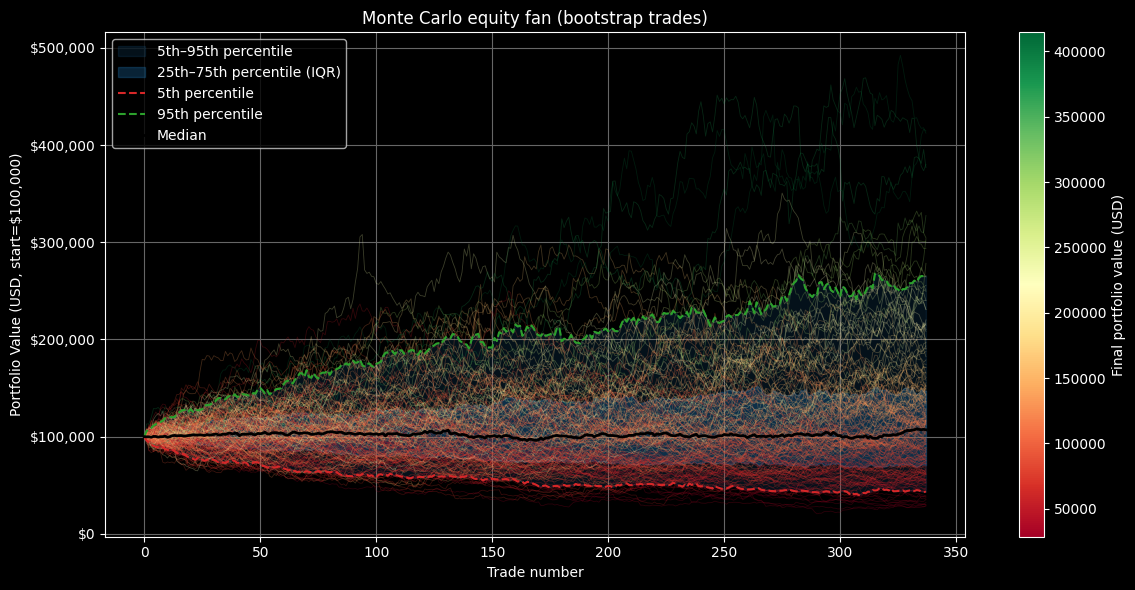

In [ ]:
# Page 12: Monte Carlo equity fan (build fan from many resampled trade sequences)
if not trades_df.empty:
    sims = []
    m = len(trades_df)
    for _ in range(min(200, MC_SIMULATIONS)):
        sample = np.random.choice(trades_df['pnl'].values, size=m, replace=True)
        caps = [INITIAL_CAPITAL]
        cap = INITIAL_CAPITAL
        for r in sample:
            cap *= (1 + r)
            caps.append(cap)
        sims.append(caps)
    sims = np.array([(np.array(s) / np.array(s)[0]) * INITIAL_CAPITAL for s in sims])

    # --- Compute percentile bands ---
    p5  = np.percentile(sims, 5,  axis=0)
    p25 = np.percentile(sims, 25, axis=0)
    p75 = np.percentile(sims, 75, axis=0)
    p95 = np.percentile(sims, 95, axis=0)
    med = np.median(sims, axis=0)
    x   = np.arange(sims.shape[1])

    fig, ax = plt.subplots(figsize=(12, 6))

    # Shaded bands
    ax.fill_between(x, p5,  p95, color='tab:blue',  alpha=0.15, label='5th–95th percentile')
    ax.fill_between(x, p25, p75, color='tab:blue',  alpha=0.30, label='25th–75th percentile (IQR)')

    # Individual simulation lines — colour-mapped by final value
    final_vals = sims[:, -1]
    norm = plt.Normalize(vmin=final_vals.min(), vmax=final_vals.max())
    cmap = plt.cm.RdYlGn
    for i, s in enumerate(sims):
        ax.plot(s, color=cmap(norm(final_vals[i])), alpha=0.25, linewidth=0.6)

    # Overlay key percentile lines
    ax.plot(x, p5,  color='tab:red',   linewidth=1.5, linestyle='--', label='5th percentile')
    ax.plot(x, p95, color='tab:green', linewidth=1.5, linestyle='--', label='95th percentile')
    ax.plot(x, med, color='black',     linewidth=2.0, label='Median')

    # Colourbar for the individual lines
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label=f'Final portfolio value (USD)')
    fmt_usd(ax)

    ax.set_title('Monte Carlo equity fan (bootstrap trades)')
    ax.set_xlabel('Trade number')
    ax.set_ylabel(f'Portfolio Value (USD, start=${INITIAL_CAPITAL:,})')
    ax.legend(loc='upper left')
    ax.grid(True, color='#666666') # Added grid
    plt.tight_layout()
    plt.show()
else:
    print('Not enough trades for MC equity fan')


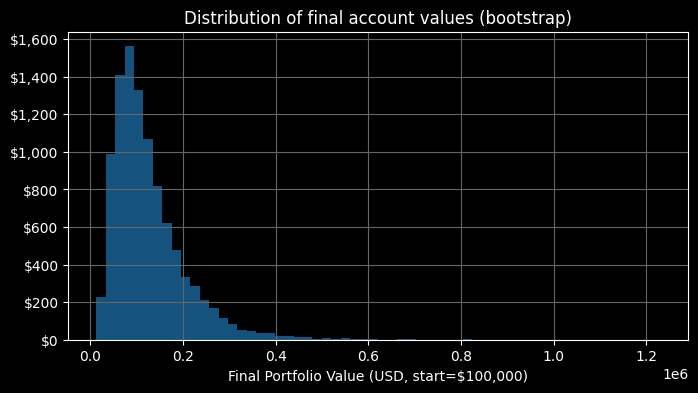

In [ ]:
# Page 13: Distribution of final account values (histogram)
if not trades_df.empty:
    fig, ax = plt.subplots(figsize=(8,4))
    ax.hist(mc_results * INITIAL_CAPITAL, bins=60, color='tab:blue', alpha=0.7)
    ax.set_title('Distribution of final account values (bootstrap)')
    ax.set_xlabel(f'Final Portfolio Value (USD, start=${INITIAL_CAPITAL:,})')
    fmt_usd(ax)
    ax.grid(True, color='#666666') # Add grid to this plot
    plt.show()
else:
    print('No MC results to plot distribution')


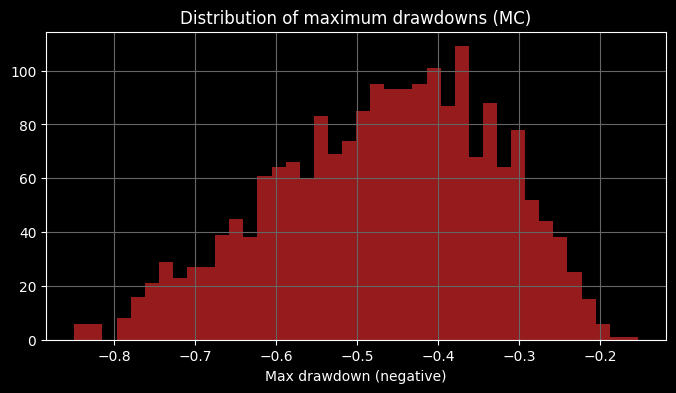

In [ ]:
# Page 14: Distribution of maximum drawdowns from MC runs
# For each MC run we can compute the path drawdown and collect max drawdown
if not trades_df.empty:
    m = len(trades_df)
    mc_maxdds = []
    for _ in range(min(MC_SIMULATIONS,2000)):
        sample = np.random.choice(trades_df['pnl'].values, size=m, replace=True)
        caps = [1.0]
        cap = 1.0
        for r in sample:
            cap *= (1+r)
            caps.append(cap)
        caps = np.array(caps)
        dd, _ = compute_drawdown(pd.Series(caps))
        mc_maxdds.append(dd.min())
    plt.figure(figsize=(8,4))
    ax = plt.gca() # Get current axes to apply grid
    ax.hist(mc_maxdds, bins=40, color='tab:red', alpha=0.7)
    ax.set_title('Distribution of maximum drawdowns (MC)')
    ax.set_xlabel('Max drawdown (negative)')
    ax.grid(True, color='#666666') # Add grid to this plot
    plt.show()
else:
    print('No trades for MC drawdown distribution')


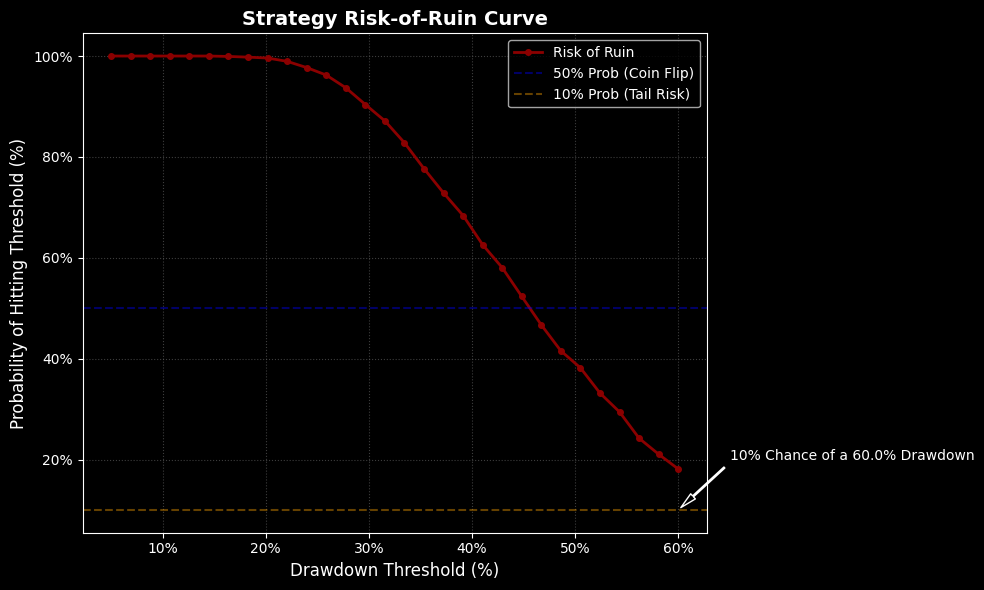

In [ ]:
# Page 15: Risk-of-Ruin Analysis (Probability of Drawdown)
if not trades_df.empty:
    # Convert PnL % to decimal returns
    returns = trades_df['pnl_pct'].values / 100

    # 2. Simulation Settings
    num_sims = MC_SIMULATIONS
    initial_capital = 100000
    # Define the "Ruin" thresholds (drawdown levels) to test
    thresholds = np.linspace(0.05, 0.60, 30)
    risk_of_ruin = []

    # 3. Run Monte Carlo for each threshold
    # Note: This might take 1-2 seconds to run
    for t in thresholds:
        ruined_count = 0
        for _ in range(num_sims):
            # Resample trades with replacement to create a new possible history
            sampled = np.random.choice(returns, size=len(returns), replace=True)
            equity_path = np.cumprod(1 + sampled)

            # Calculate drawdown of this specific path
            running_max = np.maximum.accumulate(equity_path)
            drawdown = (equity_path - running_max) / running_max

            # If the max drawdown in this path is worse than the threshold, it's 'ruin'
            if np.min(drawdown) <= -t:
                ruined_count += 1

        risk_of_ruin.append(ruined_count / num_sims)

    # 4. Plotting the Curve
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(thresholds * 100, np.array(risk_of_ruin) * 100,
            marker='o', color='darkred', linewidth=2, markersize=4, label='Risk of Ruin')

    # Add Reference Lines for Professional Assessment
    ax.axhline(50, color='blue', linestyle='--', alpha=0.4, label='50% Prob (Coin Flip)')
    ax.axhline(10, color='orange', linestyle='--', alpha=0.4, label='10% Prob (Tail Risk)')

    # Formatting
    ax.set_title('Strategy Risk-of-Ruin Curve', fontsize=14, fontweight='bold')
    ax.set_xlabel('Drawdown Threshold (%)', fontsize=12)
    ax.set_ylabel('Probability of Hitting Threshold (%)', fontsize=12)

    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

    ax.grid(True, linestyle=':', alpha=0.6, color='#666666')
    ax.legend()

    # Text Annotation for the 10% Risk Threshold
    # Find approximately where probability hits 10%
    idx_10 = np.argmin(np.abs(np.array(risk_of_ruin) - 0.10))
    ax.annotate(f'10% Chance of a {thresholds[idx_10]*100:.1f}% Drawdown',
                xy=(thresholds[idx_10]*100, 10), xytext=(thresholds[idx_10]*100 + 5, 20),
                arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

    plt.tight_layout()
    plt.show()
else:
    print("No trade data available to run simulation.")


Notes:
- The notebook recomputes trades and Monte Carlo bootstrap from the extracted trade PnLs for the PSAR strategy.
- If you prefer mark-to-market trade-level equity (intraday) or different entry/exit price rules, update the trade extraction cell accordingly.
- For large MC_SIMULATIONS values the Monte Carlo cells may take longer to run; reduce to 500 for quick exploration.

## Kernel State
No notable variables in the kernel yet.
Here are some of the files available in the kernel:
* /content/PSAR_Strategy.rtf
* /content/sample_data/README.md
* /content/sample_data/anscombe.json
* /content/sample_data/california_housing_test.csv
* /content/sample_data/mnist_test.csv
* /content/sample_data/mnist_train_small.csv
* /content/sample_data/california_housing_train.csv
* /content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
* /content/.config/default_configs.db
* /content/.config/gce
* /content/.config/.last_opt_in_prompt.yaml
* /content/.config/.last_survey_prompt.yaml
* /content/.config/.last_update_check.json
* /content/.config/active_config
* /content/.config/config_sentinel
* /content/.config/configurations/config_default